In [ ]:
#python -m torch.distributed.launch --nproc_per_node=1     --use_env main.py     --model ReMamber_Conv_PEFT     --output_dir ./test_training     --if_amp     --batch_size 4   --finetune pretrain/ReMamber_Conv.pth --data-set refzom

In [ ]:
#python -m torch.distributed.launch   --nproc_per_node=1   --use_env   main.py     --model=ReMamber_Conv     --output_dir=./outputs     --if_amp     --batch_size=8     --finetune=pretrain/ReMamber_Conv.pth     --data-set=refzom     --lr=9e-6     --partial-freeze

In [1]:
import argparse
import datetime
import json
import time
from contextlib import suppress
from pathlib import Path

import numpy as np
import torch
import torch.backends.cudnn as cudnn
from timm.models import create_model
from timm.scheduler import create_scheduler
from timm.utils import ModelEma, NativeScaler, get_state_dict

import model.conv_segmenter
import model.mamba_segmenter
import utils as utils
from engine import evaluate, train_one_epoch
from model.utils import create_optimizer
from ref_dataset import build_dataset, collate_fn
import model.conv_segmenter_peft

config = {
    "batch_size": 2,
    "epochs": 50,
    "model": "ReMamber_Conv",
    "pretrain_path": "./pretrain",
    "input_size": 480,
    "drop": 0.0,
    "drop_path": 0.1,
    "model_ema": False,
    "model_ema_decay": 0.9999,
    "model_ema_force_cpu": False,
    "opt": "adamw",
    "opt_eps": 1e-08,
    "opt_betas": None,
    "clip_grad": None,
    "momentum": 0.9,
    "weight_decay": 0.0001,
    "sched": "cosine",
    "lr": 5e-05,
    "lr_decoder": 5e-05,
    "lr_backbone": 2.5e-05,
    "lr_vssm": 2.5e-05,
    "warmup_lr": 1e-06,
    "min_lr": 1e-06,
    "decay_epochs": 30,
    "warmup_epochs": 0,
    "cooldown_epochs": 10,
    "patience_epochs": 10,
    "decay_rate": 0.1,
    "train_mode": True,
    "finetune": "test_training/best_checkpoint.pth",
    "data_path": "./ref_dataset/data",
    "data_set": "refzom", #"refcoco",
    "output_dir": "./test_training",
    "device": "cuda",
    "seed": 0,
    "resume": "",
    "start_epoch": 0,
    "eval": False,
    "dist_eval": False,
    "num_workers": 8,
    "pin_mem": True,
    "distributed": True,
    "world_size": 1,
    "dist_url": "env://",
    "if_amp": True,
    "debug_mode": True,
    "local_rank": 0,
    "use_dense_aligner": True,
    "use_text_adapter": True,
    "da_layers": "1,3,5,7,9,11",
    "ta_layers": "1,3,5,7,9,11",
    "da_dim": 128,
    "ta_dim": 64,
    "rank": 0,
    "gpu": 0,
    "dist_backend": "nccl"
}



/home/akula.ha/.conda/envs/refseg/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [25]:
from types import SimpleNamespace

# Convert dictionary to namespace
args = config_obj = SimpleNamespace(**config)

In [26]:
#python -m torch.distributed.launch --nproc_per_node=1     --use_env main.py     --model ReMamber_Conv_PEFT     --output_dir ./test_training     --if_amp     --batch_size 2   --finetune pretrain/ReMamber_Conv.pth --data-set refzom

In [27]:
from vmamba_model.vmamba import VSSBlock as OriginalVSSBlock  # or wherever it's defined
VSSBlockType = OriginalVSSBlock  # for isinstance checks later

#### base segmenter.py

In [29]:
import torch.nn as nn
import torch.nn.functional as F
from transformers import CLIPTextModel, CLIPTokenizerFast
from peft import LoraConfig, get_peft_model, TaskType

from model.utils import dice_loss, sigmoid_focal_loss

class BaseSegmenter(nn.Module):
    def __init__(self, backbone, **kwargs):
        super().__init__()
        self.backbone = backbone
        self.decoder = None

        self.tokenizer = CLIPTokenizerFast.from_pretrained(
            "openai/clip-vit-large-patch14"
        )

        # — load base CLIP text encoder —
        base_text = CLIPTextModel.from_pretrained(
            "openai/clip-vit-large-patch14"
        )

        # — configure LoRA —
        lora_cfg = LoraConfig(
            task_type=TaskType.SEQ_CLS,    # encoder‐only
            inference_mode=False,          # we’re fine‐tuning
            r=8,                           # LoRA rank
            lora_alpha=32,
            lora_dropout=0.1,
            target_modules=["q_proj", "k_proj", "v_proj", "out_proj"],
        )

        # — wrap with LoRA adapters (freezes base_text) —
        self.text_encoder = get_peft_model(base_text, lora_cfg)

def forward(self, x, text, mask=None, **kwargs):
        # Tokenize input text
        encoding = self.tokenizer(
            text,
            padding='max_length',
            truncation=True,
            max_length=20,
            return_tensors='pt'
        )
        input_ids = encoding['input_ids'].to(x.device, non_blocking=True)
        attention_mask = encoding['attention_mask'].to(x.device, non_blocking=True)

        # Encode text with LoRA-adapted encoder
        ret = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=False,
            return_dict=True
        )
        l_feats = ret.last_hidden_state  # (B, N_l, C)
        l_feats = l_feats.permute(0, 2, 1)  # (B, C, N_l)
        l_mask = attention_mask.unsqueeze(-1)  # (B, N_l, 1)

        # Extract optional pooled output
        pooler_out = ret.pooler_output if hasattr(ret, "pooler_output") else None

        # Pass through backbone and decoder
        features = self.backbone(x, l_feats, l_mask, pooler_out=pooler_out)
        x_c1, x_c2, x_c3, x_c4 = features
        pred = self.decoder([x_c4, x_c3, x_c2, x_c1], l_feats, l_mask)
        pred = F.interpolate(pred, x.shape[-2:], mode='bilinear', align_corners=True)

        # Compute loss during training
        if self.training:
            loss = dice_loss(pred, mask) + sigmoid_focal_loss(pred, mask, alpha=-1, gamma=0)
            return pred.detach(), mask, loss
        else:
            return pred.detach()

#### conv_segmenter.py

In [30]:
import math

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from timm.models.registry import register_model

#from model.base_segmenter import BaseSegmenter
#from .customized_model import ReMamber
from model.utils import load_ckpt, update_mamba_config
#from .dense_alignment import CrossAligner, DenseAligner, DenseMixtureOfConvolution


class Conv2d_BN(nn.Module):
    """Convolution with BN module."""
    def __init__(
        self,
        in_ch,
        out_ch,
        kernel_size=1,
        stride=1,
        pad=0,
        dilation=1,
        groups=1,
        bn_weight_init=1,
        norm_layer=nn.BatchNorm2d,
        act_layer=None,
    ):
        super().__init__()

        self.conv = torch.nn.Conv2d(in_ch,
                                    out_ch,
                                    kernel_size,
                                    stride,
                                    pad,
                                    dilation,
                                    groups,
                                    bias=False)
        self.bn = norm_layer(out_ch)
        torch.nn.init.constant_(self.bn.weight, bn_weight_init)
        torch.nn.init.constant_(self.bn.bias, 0)
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                # Note that there is no bias due to BN
                fan_out = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(mean=0.0, std=np.sqrt(2.0 / fan_out))

        self.act_layer = act_layer() if act_layer is not None else nn.Identity()

    def forward(self, x):
        """foward function"""
        x = self.conv(x)
        x = self.bn(x)
        x = self.act_layer(x)

        return x


class ResBlock(nn.Module):
    """Residual block for convolutional local feature."""
    def __init__(
        self,
        in_features,
        hidden_features=None,
        out_features=None,
        act_layer=nn.Hardswish,
        norm_layer=nn.BatchNorm2d,
    ):
        super().__init__()

        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.conv1 = Conv2d_BN(in_features,
                               hidden_features,
                               act_layer=act_layer)
        self.dwconv = nn.Conv2d(
            hidden_features,
            hidden_features,
            3,
            1,
            1,
            bias=False,
            groups=hidden_features,
        )
        self.norm = norm_layer(hidden_features)
        self.act = act_layer()
        self.conv2 = Conv2d_BN(hidden_features, out_features)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        """
        initialization
        """
        if isinstance(m, nn.Conv2d):
            fan_out = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
            fan_out //= m.groups
            m.weight.data.normal_(0, math.sqrt(2.0 / fan_out))
            if m.bias is not None:
                m.bias.data.zero_()
        elif isinstance(m, nn.BatchNorm2d):
            m.weight.data.fill_(1)
            m.bias.data.zero_()

    def forward(self, x):
        """foward function"""
        identity = x
        feat = self.conv1(x)
        feat = self.dwconv(feat)
        feat = self.norm(feat)
        feat = self.act(feat)
        feat = self.conv2(feat)
        return feat
        # return identity + feat

class ConvDecoderAdapter(nn.Module):
    def __init__(self, in_dim, reduction_factor=4):
        super().__init__()
        hidden_dim = in_dim // reduction_factor
        self.down = nn.Conv2d(in_dim, hidden_dim, 1)
        self.d_moc = DenseMixtureOfConvolution(hidden_dim)
        self.up = nn.Conv2d(hidden_dim, in_dim, 1)
        self.act = nn.ReLU()
        
    def forward(self, x):
        residual = x
        x = self.down(x)
        x = self.act(x)
        x = self.d_moc(x)
        x = self.up(x)
        return x + residual

class ConvDecoder_PEFT(nn.Module):
    """Modified ConvDecoder with adapters"""
    def __init__(self, in_dim, **kwargs) -> None:
        super().__init__()
        self.in_dim = [in_dim*8, in_dim*4, in_dim*2, in_dim]
        self.hidden_dim = in_dim*4

        self.mixer3 = ResBlock(in_dim*8, out_features=self.hidden_dim)
        self.mixer2 = ResBlock(in_dim*4+self.hidden_dim, out_features=self.hidden_dim)
        self.mixer1 = ResBlock(in_dim*2+self.hidden_dim, out_features=self.hidden_dim)

        # Add decoder adapters
        self.adapter3 = ConvDecoderAdapter(self.hidden_dim)
        self.adapter2 = ConvDecoderAdapter(self.hidden_dim)
        self.adapter1 = ConvDecoderAdapter(self.hidden_dim)
        #print("creating adapters")
        self.neck = nn.Sequential(
            nn.Conv2d(self.hidden_dim+in_dim, self.hidden_dim, 3, padding=1),
            nn.BatchNorm2d(self.hidden_dim),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            nn.Conv2d(self.hidden_dim, self.hidden_dim, 3, padding=1),
            nn.BatchNorm2d(self.hidden_dim),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            nn.Conv2d(self.hidden_dim, 1, 3, padding=1)
        )
        
        # Add neck adapter
        self.neck_adapter = ConvDecoderAdapter(self.hidden_dim)
    
    def forward(self, x, *args):
        out0, out1, out2, out3 = x
        out = self.mixer3(out0)
        # Apply adapter
        out = out + self.adapter3(out)
        out = F.interpolate(out, scale_factor=2, mode='bilinear', align_corners=True)
        
        out = self.mixer2(torch.cat([out, out1], dim=1))
        # Apply adapter
        out = out + self.adapter2(out)
        out = F.interpolate(out, scale_factor=2, mode='bilinear', align_corners=True)
        
        out = self.mixer1(torch.cat([out, out2], dim=1))
        # Apply adapter
        out = out + self.adapter1(out)
        out = F.interpolate(out, scale_factor=2, mode='bilinear', align_corners=True)

        # Process first part of neck
        tmp = torch.cat([out, out3], dim=1)
        out = self.neck[0](tmp)  # Conv
        out = self.neck[1](out)  # BN
        out = self.neck[2](out)  # ReLU
        
        # Apply neck adapter
        out = out + self.neck_adapter(out)
        
        # Process remaining layers
        for layer in self.neck[3:]:
            out = layer(out)

        return out

class ConvSegmentor_PEFT(BaseSegmenter):
    def __init__(self, backbone, img_size=256, patch_size=4, embed_dim=256, **kwargs):
        super().__init__(backbone)
        #print("kwargs", kwargs)
        res = img_size // patch_size
        self.decoder = ConvDecoder_PEFT(in_dim=embed_dim, resolution=res)


#@register_model
def ReMamber_Conv_PEFT(img_size, model_size="base", **kwargs):
    # This function remains unchanged
    config_dict = update_mamba_config(model_size)
    backbone = ReMamber_PEFT(**config_dict)
    backbone, ret = load_ckpt(backbone, model_size)
    model = ConvSegmentor_PEFT(backbone, img_size=img_size, embed_dim=config_dict['dims'][0], patch_size=config_dict['patch_size'])
    return model, ret[0]

In [31]:
from vmamba_model.vmamba import VSSBlock as OriginalVSSBlock

class BasicConvAdapter(nn.Module):
    def __init__(self, dim, reduction=4):
        super().__init__()
        hidden_dim = dim // reduction
        self.down = nn.Conv2d(dim, hidden_dim, kernel_size=1)
        self.act = nn.ReLU()
        self.up = nn.Conv2d(hidden_dim, dim, kernel_size=1)
        self.alpha = nn.Parameter(torch.tensor(0.0))

    def forward(self, block_out, x_input):
        residual = self.up(self.act(self.down(x_input)))
        return block_out + self.alpha * residual


#### Dense Aligner py

In [32]:
import math

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from timm.models.registry import register_model

class BasicConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, **kwargs):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, bias=False, **kwargs)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
    
    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        return x

class DenseMixtureOfConvolution(nn.Module):
    """
    Dense Mixture of Convolutions (D-MoC) core:
      - 1×1 branch
      - 3×3 branch (dense: sees input + branch1)
      - 5×5 branch (dense: sees input + branch1 + branch2)
      - concat branches + add input residual
    """
    def __init__(self, in_channels):
        super().__init__()
        # split channels so sum equals in_channels
        ch1 = in_channels // 2
        ch2 = in_channels // 4
        ch3 = in_channels - ch1 - ch2

        self.branch1 = BasicConv2d(in_channels, ch1, kernel_size=1)
        self.branch2 = BasicConv2d(in_channels + ch1, ch2, kernel_size=3, padding=1)
        self.branch3 = BasicConv2d(in_channels + ch1 + ch2, ch3, kernel_size=5, padding=2)

    def forward(self, x):
        # x: (B, C, H, W)
        b1 = self.branch1(x)
        b2 = self.branch2(torch.cat([x, b1], dim=1))
        b3 = self.branch3(torch.cat([x, b1, b2], dim=1))
        out = torch.cat([b1, b2, b3], dim=1)
        # residual add (channels match in_channels)
        return out + x


In [33]:
class CrossTwister(nn.Module):
    """
    Mamba Twister fusion that projects both image and text into a shared embed_dim,
    then applies global token + local fusion inside a VSSLayer Twister block.
    """
    def __init__(self, img_dim, txt_dim, embed_dim, cfg):
        super().__init__()
        # store config
        self.cfg = cfg
        # 1) project image channels -> embed_dim via 1x1 conv
        # image is already projected outside, img_dim = embed_dim
        self.img_proj = nn.Identity() #nn.Conv2d(img_dim, embed_dim, kernel_size=1)
        # 2) project text embeddings -> embed_dim via linear
        self.txt_proj = nn.Linear(txt_dim, embed_dim)
        # ReMamber norm & act lookups
        _NORMLAYERS = dict(ln=nn.LayerNorm, ln2d=LayerNorm2d, bn=nn.BatchNorm2d)
        _ACTLAYERS  = dict(silu=nn.SiLU, gelu=nn.GELU, relu=nn.ReLU, sigmoid=nn.Sigmoid)
        norm_layer    = _NORMLAYERS[cfg['norm_layer'].lower()]
        ssm_act_layer = _ACTLAYERS[cfg['ssm_act_layer'].lower()]
        # 3) one-layer VSS Twister at embed_dim
        self.vss = VSSLayer(
            dim             = embed_dim,
            depth           = 1,
            use_checkpoint  = cfg['use_checkpoint'],
            norm_layer      = norm_layer,
            ssm_act_layer   = ssm_act_layer,
            downsample      = None,
            channel_first   = cfg['channel_first'],
            # SSM params from config
            ssm_d_state     = cfg['ssm_d_state'],
            ssm_ratio       = 1, #cfg['ssm_ratio'],
            ssm_dt_rank     = 1, #cfg['ssm_dt_rank'],
            ssm_conv        = cfg['ssm_conv'],
            ssm_conv_bias   = cfg['ssm_conv_bias'],
            ssm_drop_rate   = cfg['ssm_drop_rate'],
            ssm_init        = cfg['ssm_init'],
            forward_type    = cfg['forward_type'],
            # dummy MLP args
            mlp_ratio       = cfg['mlp_ratio'],
            mlp_act_layer   = cfg['mlp_act_layer'],
            mlp_drop_rate   = cfg['mlp_drop_rate'],
            gmlp            = cfg['gmlp'],
            forward_coremm  = 'Twister',
        )
        # global guidance MLP mapped from embed_dim (post txt_proj)
        #self.global_mlp = nn.Sequential(nn.Linear(embed_dim, embed_dim), nn.ReLU())
        # using projected text output as input for global mlp
        self.global_mlp = nn.Sequential(nn.Identity(), nn.ReLU())
        # local fusion expects embed_dim for text and visual dims
        hidden_dim = 128
        self.local_fuser = ImageTextCorr(
            visual_dim = embed_dim,
            text_dim   = embed_dim,
            hidden_dim = hidden_dim,
            out_dim    = embed_dim,
        )

    def forward(self, img, l_feat, l_mask, pooler_out=None):
        """
        img:       [B, img_dim, H, W]
        l_feat:    [B, txt_dim, L] or [B, L, txt_dim]
        l_mask:    [B, L]
        pooler_out:[B, txt_dim] opt override
        """
        B, _, H, W = img.shape
        # 1) project image -> embed_dim
        img_e = self.img_proj(img)  # [B, embed_dim, H, W]
        # 2) ensure l_feat in [B, L, txt_dim]
        if l_feat.dim()==3 and l_feat.shape[1]!=l_feat.shape[-1]:
            l_feat = l_feat.transpose(1,2)
        # 3) project each text token -> embed_dim
        txt_seq = self.txt_proj(l_feat)  # [B, L, embed_dim]
        # override pooling via projected pooler_out if given
        if pooler_out is not None:
            pool = self.txt_proj(pooler_out)  # [B, embed_dim]
        else:
            pool = txt_seq[:,0]               # token0
        # 4) global cond -> broadcast to spatial
        g = self.global_mlp(pool)           # [B, embed_dim]
        global_cond = g.unsqueeze(-1).unsqueeze(-1).expand(-1, -1, H, W)
        # 5) local fusion map from embedded img & txt
        local = self.local_fuser(img_e, txt_seq.transpose(1,2), l_mask)
        local_cond = einops.rearrange(local, 'b h w c -> b c h w', h=H)
        # 6) Twister on (img_e, global_cond, local_cond)
        fused, _ = self.vss((img_e, global_cond, local_cond), txt_seq, l_mask)
        # fused[0] has shape [B, embed_dim, H, W]
        return fused[0]


# ============== DenseAligner (uses CrossTwister) ================
class DenseAligner(nn.Module):
    """
    Adapter that downsamples image to a reduced dim, applies D-MoC,
    fuses via CrossTwister, then upsamples back to original dim.
    """
    def __init__(self, dim, text_dim=768, reduction_factor=4, cfg=None):
        super().__init__()
        self.cfg = cfg
        # 1) image normalization + down-projection
        self.norm = nn.LayerNorm(dim)
        reduced = 128 #dim // reduction_factor
        self.img_down = nn.Linear(dim, reduced)
        self.act = nn.ReLU()    
        # 2) dense mixture of convolution at reduced dim
        self.d_moc = DenseMixtureOfConvolution(reduced)
        # 3) cross-modal Twister fusion at reduced dim
        self.cross_twister = CrossTwister(
            img_dim   = reduced,
            txt_dim   = text_dim,
            embed_dim = reduced,
            cfg       = cfg,
        )
        # 4) up-projection back to original dim
        self.img_up = nn.Linear(reduced, dim)
        self.alpha = nn.Parameter(torch.tensor(1.0))  # Initialize with 1.0 (no effect initially)


    def forward(self, x, l_feat, l_mask, pooler_out=None):
        B, C, H, W = x.shape
        # 1) Norm and down-project image
        xi = einops.rearrange(x, 'b c h w -> b h w c')
        xi = self.norm(xi)
        xi = einops.rearrange(xi, 'b h w c -> b (h w) c')
        xi = self.img_down(xi)
        xi = self.act(xi)
        xi = einops.rearrange(xi, 'b (h w) c -> b c h w', h=H, w=W)
        # 2) Dense mixture of convolutions
        xdm = self.d_moc(xi)
        # 3) Cross-modal fusion via Twister
        xf = self.cross_twister(xdm, l_feat, l_mask, pooler_out)
        # 4) Residual at reduced scale
        xf = xf + xi
        # 5) Up-project back and final residual
        xu = einops.rearrange(xf, 'b c h w -> b (h w) c')
        xu = self.img_up(xu)
        xu = einops.rearrange(xu, 'b (h w) c -> b c h w', h=H, w=W)
        return x + self.alpha * xu


In [34]:
import torch
import torch.nn as nn
import einops

class ImageAdapter(nn.Module):
    """
    Lightweight image adapter:
    - Normalizes and downsamples the image.
    - Applies a Dense Mixture of Convolutions.
    - Residual connection at reduced scale.
    - Upsamples back and scales with a learnable alpha.
    """
    def __init__(self, dim, reduction_factor=4):
        super().__init__()
        reduced = dim // reduction_factor

        self.norm = nn.LayerNorm(dim)
        self.img_down = nn.Linear(dim, reduced)
        self.act = nn.ReLU()

        self.d_moc = DenseMixtureOfConvolution(reduced)

        self.img_up = nn.Linear(reduced, dim)

        # Learnable residual scale
        self.alpha = nn.Parameter(torch.tensor(1.0))

    def forward(self, x, l_feat=None, l_mask=None, pooler_out=None):
        """
        Args:
            x: [B, C, H, W] input image features
            (l_feat, l_mask, pooler_out): unused in this variant
        Returns:
            [B, C, H, W] scaled residual output
        """
        B, C, H, W = x.shape

        # 1. Normalize and down-project
        xi = einops.rearrange(x, 'b c h w -> b h w c')
        xi = self.norm(xi)
        xi = einops.rearrange(xi, 'b h w c -> b (h w) c')
        xi = self.img_down(xi)  # [B, H*W, reduced]
        xinit = xi
        xi = self.act(xi)
        xi = einops.rearrange(xi, 'b (h w) c -> b c h w', h=H, w=W)

        # 2. Apply DenseMixtureOfConvolution
        xdm = self.d_moc(xi)  # [B, reduced, H, W]

        # 3. Residual at reduced scale
        xf = xdm + einops.rearrange(xinit, 'b (h w) c -> b c h w', h=H, w=W)

        # 4. Up-project to original dim
        xu = einops.rearrange(xf, 'b c h w -> b (h w) c')
        xu = self.img_up(xu)
        xu = einops.rearrange(xu, 'b (h w) c -> b c h w', h=H, w=W)

        # 5. Return scaled residual output
        return self.alpha * xu


In [35]:
import math

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.checkpoint as checkpoint
from timm.models.layers import DropPath

DropPath.__repr__ = lambda self: f"timm.DropPath({self.drop_prob})"

import einops

from vmamba_model.vmamba import SS2D, VSSM, LayerNorm2d, Linear2d

from model.utils import ImageTextCorr

class Twister(nn.Module):
    def __init__(
            self,         
            # basic dims ===========
            d_model=96,
            d_state=16,
            ssm_ratio=2.0,
            dt_rank="auto",
            act_layer=nn.SiLU,
            # dwconv ===============
            d_conv=3, # < 2 means no conv 
            conv_bias=True,
            # ======================
            dropout=0.0,
            bias=False,
            # dt init ==============
            dt_min=0.001,
            dt_max=0.1,
            dt_init="random",
            dt_scale=1.0,
            dt_init_floor=1e-4,
            initialize="v0",
            # ======================
            forward_type="v2",
            channel_first=False,
            # ======================
            input_res=32,
            **kwargs,
        ):
        super().__init__()
        self.input_res = input_res
        self.ss2d = SS2D(d_model, d_state, ssm_ratio, dt_rank, act_layer, d_conv, conv_bias, dropout, bias, dt_min, dt_max, dt_init, dt_scale, dt_init_floor, initialize, forward_type, channel_first, **kwargs)
        self.ss2d.in_proj = Linear2d(d_model * 3, self.ss2d.in_proj.weight.shape[0], bias=bias)
        self.input_res = min(input_res, 16)
        forward_type_1d = "v052d"
        self.ss1d = SS2D(self.input_res**2, d_state, ssm_ratio, dt_rank, act_layer, d_conv, conv_bias, dropout, bias, dt_min, dt_max, dt_init, dt_scale, dt_init_floor, initialize, forward_type_1d, channel_first, **kwargs)
    
    def forward(self, x: torch.Tensor, **kwargs):
        img, global_cond, local_cond = x
        B, C, H, W = img.shape
        if global_cond is not None:
            x = torch.cat([img, global_cond, local_cond], dim=1) # b l 3c
        else:
            x = torch.cat([img, local_cond], dim=-1)
        x_prepaired = x
        x_mix = F.interpolate(x, size=(self.input_res,self.input_res), mode='bilinear')
        x_mix = x_mix.view(B, -1, self.input_res**2)
        x_mix = x_mix.permute(0, 2, 1).unsqueeze(-2).contiguous() # b, hw, 1, c
        x_mix = self.ss1d(x_mix)
        x_mix = x_mix.squeeze(-2).permute(0, 2, 1).contiguous() # b, c, hw
        x_mix = F.interpolate(x_mix.view(B,-1,self.input_res,self.input_res), size=(H,W), mode='bilinear')

        x = x_mix + x_prepaired
        
        out = self.ss2d(x)

        out = [out, global_cond, local_cond]
        return out

class VSSBlock(nn.Module):
    def __init__(
        self,
        forward_coremm='SS2D',
        **kwargs,
    ):
        super().__init__()
        norm_layer = kwargs['norm_layer']
        dim = kwargs['dim']
        drop_path = kwargs['drop_path']
        self.ln_1 = norm_layer(dim)
        self.forward_coremm = forward_coremm
        if not forward_coremm:
            raise
        elif forward_coremm == 'SS2D':
            self.self_attention = SS2D(
                d_model=dim,
                d_state=kwargs['ssm_d_state'],
                dt_rank=kwargs['ssm_dt_rank'],
                act_layer=kwargs['ssm_act_layer'],
                d_conv=kwargs['ssm_conv'],
                conv_bias=kwargs['ssm_conv_bias'],
                dropout=kwargs['ssm_drop_rate'],
                initialize=kwargs['ssm_init'],
                **kwargs,
            )
        elif forward_coremm == 'Twister':
            self.self_attention = Twister(
                d_model=dim,
                d_state=kwargs['ssm_d_state'],
                ssm_ratio=kwargs['ssm_ratio'],
                dt_rank=kwargs['ssm_dt_rank'],
                act_layer=kwargs['ssm_act_layer'],
                d_conv=kwargs['ssm_conv'],
                conv_bias=kwargs['ssm_conv_bias'],
                dropout=kwargs['ssm_drop_rate'],
                initialize=kwargs['ssm_init'],
                forward_type=kwargs['forward_type'],
                channel_first=kwargs['channel_first'],
            )
        else:
            raise
        self.drop_path = DropPath(drop_path)

    def forward(self, input: torch.Tensor):
        if isinstance(input, torch.Tensor):
            out = self.ln_1(input)
            out = self.self_attention(out)
            out = input + self.drop_path(out)
            x = out
        else:
            # input should be a list (img and global / local conditions)
            out = [self.ln_1(i) if i is not None else None for i in input]
            out = self.self_attention(out)
            out = [i + self.drop_path(o) if i is not None else None for i, o in zip(input, out)]
            x = out
        return x


class VSSLayer(nn.Module):
    """ A basic Swin Transformer layer for one stage.
    Args:
        dim (int): Number of input channels.
        depth (int): Number of blocks.
        drop (float, optional): Dropout rate. Default: 0.0
        attn_drop (float, optional): Attention dropout rate. Default: 0.0
        drop_path (float | tuple[float], optional): Stochastic depth rate. Default: 0.0
        norm_layer (nn.Module, optional): Normalization layer. Default: nn.LayerNorm
        downsample (nn.Module | None, optional): Downsample layer at the end of the layer. Default: None
        use_checkpoint (bool): Whether to use checkpointing to save memory. Default: False.
    """

    def __init__(
        self, 
        depth,
        downsample=None,
        forward_coremm="Twister",
        **kwargs,
    ):
        super().__init__()
        # dim = kwargs['dim']
        drop_path = 0.
        dim = kwargs['dim']
        use_checkpoint = kwargs['use_checkpoint']
        norm_layer = kwargs['norm_layer']


        self.dim = dim
        self.use_checkpoint = use_checkpoint

        self.blocks = nn.ModuleList([
            VSSBlock(
                forward_coremm=forward_coremm,
                drop_path=drop_path[i] if isinstance(drop_path, list) else drop_path,
                **kwargs,
            )
            for i in range(depth)])
        
        if True: # is this really applied? Yes, but been overriden later in VSSM!
            def _init_weights(module: nn.Module):
                for name, p in module.named_parameters():
                    if name in ["out_proj.weight"]:
                        p = p.clone().detach_() # fake init, just to keep the seed ....
                        nn.init.kaiming_uniform_(p, a=math.sqrt(5))
            self.apply(_init_weights)

        if downsample is not None:
            self.downsample = downsample(dim=dim, norm_layer=norm_layer, channel_first=kwargs['channel_first'])
        else:
            self.downsample = None

    def forward(self, x, l_feat, l_mask):
        for blk in self.blocks:
            if self.use_checkpoint:
                x = checkpoint.checkpoint(blk, x)
            else:
                x = blk(x)
        # x: b w h c
        inner = x
        if self.downsample is not None:
            x = self.downsample(x)

        return x, inner



In [36]:
from vmamba_model.vmamba import VSSBlock as OriginalVSSBlock

class ReMamber_PEFT(VSSM):
    """ReMamber with PEFT-style adapters over VSSBlocks and full multimodal pipeline"""

    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.classifier = None
        self.VSSBlockType = OriginalVSSBlock

        dims = kwargs['dims']
        use_checkpoint = kwargs['use_checkpoint']
        norm_layer_key = kwargs['norm_layer']

        self.block_adapters = nn.ModuleList()
        self.text_guidencee = nn.ModuleList()
        self.local_text_fusion = nn.ModuleList()
        self.image_adapters = nn.ModuleList()
        self.multimodal_blocks = nn.ModuleList()

        # Normalization & activation layer maps
        _NORMLAYERS = dict(ln=nn.LayerNorm, ln2d=LayerNorm2d, bn=nn.BatchNorm2d)
        norm_layer = _NORMLAYERS[norm_layer_key.lower()]
        _ACTLAYERS = dict(silu=nn.SiLU, gelu=nn.GELU, relu=nn.ReLU, sigmoid=nn.Sigmoid)
        ssm_act_layer = _ACTLAYERS[kwargs['ssm_act_layer'].lower()]

        for i_layer in range(self.num_layers):
            # Build multimodal VSS layer (your Twister-augmented version)
            layer = VSSLayer(
                dim=dims[i_layer],
                depth=2,
                use_checkpoint=use_checkpoint,
                norm_layer=norm_layer,
                ssm_act_layer=ssm_act_layer,
                downsample=None,
                channel_first=self.channel_first,
                # ===== SSM params
                ssm_d_state=kwargs['ssm_d_state'],
                ssm_ratio=kwargs['ssm_ratio'],
                ssm_dt_rank=kwargs['ssm_dt_rank'],
                ssm_conv=kwargs['ssm_conv'],
                ssm_conv_bias=kwargs['ssm_conv_bias'],
                ssm_drop_rate=kwargs['ssm_drop_rate'],
                ssm_init=kwargs['ssm_init'],
                forward_type=kwargs['forward_type'],
                # ===== MLP
                mlp_ratio=kwargs['mlp_ratio'],
                mlp_act_layer=kwargs['mlp_act_layer'],
                mlp_drop_rate=kwargs['mlp_drop_rate'],
                gmlp=kwargs['gmlp'],
                forward_coremm='Twister',
            )
            self.multimodal_blocks.append(layer)

            # Adapter list over each VSSBlock inside this layer
            adapter_list = nn.ModuleList()
            vss_layer = self.layers[i_layer]
            
            for j, block in enumerate(vss_layer.blocks):
                if isinstance(block, self.VSSBlockType) and j % 2 == 0:  # Apply to every other block
                    dim = block.norm.normalized_shape[0]
                    adapter = DenseAligner(dim=dim, cfg={**kwargs, "channel_first": self.channel_first})
                else:
                    adapter = nn.Identity()  # Or use a no-op wrapper if needed
                adapter_list.append(adapter)

            self.block_adapters.append(adapter_list)

            # Text -> channel-wise guidence MLP
            self.text_guidencee.append(
                nn.Sequential(nn.Linear(768, dims[i_layer]), nn.ReLU())
            )

            # Spatial multimodal fuser
            self.local_text_fusion.append(
                ImageTextCorr(
                    visual_dim=dims[i_layer],
                    text_dim=768,
                    hidden_dim=512,
                    out_dim=dims[i_layer],
                )
            )

            # Final adapter over fused image feature
            self.image_adapters.append(ImageAdapter(dims[i_layer]))

    def forward_layer(self, x, layer, adapters, l_feat, l_mask, pooler_out):
        blocks = layer[0]
        for block, adapter in zip(blocks, adapters):
            x_in = x
            block_out = block(x_in)
            #x = adapter(block_out, l_feat, l_mask, pooler_out)  # Adapter adds residual inside
            if isinstance(adapter, nn.Identity):
                adapter_feats = x_in  # no-op
            else:
                adapter_feats = adapter(x_in, l_feat, l_mask, pooler_out)

            x = block_out + (adapter_feats - x_in)  

        inner = x  # Before downsampling
        if len(layer) > 1:
            x = layer[1](x)  # Downsample
        return x, inner

    def forward(self, x, l_feat, l_mask, pooler_out=None):
        x = self.patch_embed(x)
        outs = []

        for i, layer in enumerate(self.layers):
            x, inner = self.forward_layer(x, layer, self.block_adapters[i], l_feat, l_mask, pooler_out)
            _, c, h, w = inner.shape
            out = inner

            pooling_text = l_feat[..., 0] if pooler_out is None else pooler_out
            text_guidence = self.text_guidencee[i](pooling_text)
            text_guidence = einops.repeat(text_guidence, "b c -> b c h w", h=h, w=w)

            local_text = self.local_text_fusion[i](out, l_feat, l_mask)
            local_text = einops.rearrange(local_text, 'b h w c -> b c h w', h=h)

            mm_input = (out, text_guidence, local_text)
            ret = self.multimodal_blocks[i](mm_input, None, None)[0]
            img_feat = ret[0]

            adapter_out = self.image_adapters[i](out)
            img_feat = img_feat + adapter_out

            if len(layer) > 1:
                x = layer[1](img_feat)  # Downsample final fused feature
            else:
                x = img_feat

            outs.append(img_feat)

        return outs


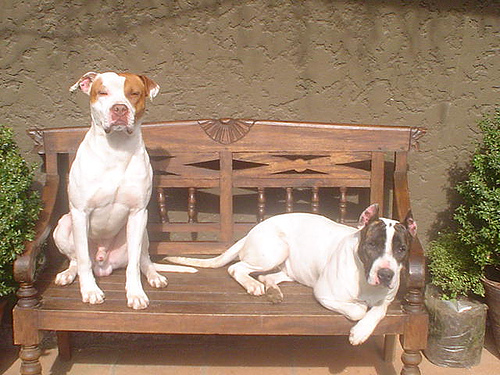

In [37]:
# read the image
from PIL import Image
input_img = Image.open("assets/demo_image.jpg")
input_img

In [38]:
model, _ = ReMamber_Conv_PEFT(config["input_size"], model_size="base", **config)

# ReMamber_Conv("ReMamber_Conv",
#     img_size=config["input_size"],
#     model_size="base",)

['patch_embed.0.weight', 'patch_embed.0.bias', 'patch_embed.2.weight', 'patch_embed.2.bias', 'patch_embed.5.weight', 'patch_embed.5.bias', 'patch_embed.7.weight', 'patch_embed.7.bias', 'layers.0.blocks.0.norm.weight', 'layers.0.blocks.0.norm.bias', 'layers.0.blocks.0.op.x_proj_weight', 'layers.0.blocks.0.op.dt_projs_weight', 'layers.0.blocks.0.op.dt_projs_bias', 'layers.0.blocks.0.op.A_logs', 'layers.0.blocks.0.op.Ds', 'layers.0.blocks.0.op.out_norm.weight', 'layers.0.blocks.0.op.out_norm.bias', 'layers.0.blocks.0.op.in_proj.weight', 'layers.0.blocks.0.op.conv2d.weight', 'layers.0.blocks.0.op.out_proj.weight', 'layers.0.blocks.0.norm2.weight', 'layers.0.blocks.0.norm2.bias', 'layers.0.blocks.0.mlp.fc1.weight', 'layers.0.blocks.0.mlp.fc1.bias', 'layers.0.blocks.0.mlp.fc2.weight', 'layers.0.blocks.0.mlp.fc2.bias', 'layers.0.blocks.1.norm.weight', 'layers.0.blocks.1.norm.bias', 'layers.0.blocks.1.op.x_proj_weight', 'layers.0.blocks.1.op.dt_projs_weight', 'layers.0.blocks.1.op.dt_projs_bia

In [39]:
decoder_params = sum(p.numel() for p in model.decoder.parameters() if p.requires_grad)
print(f"Decoder Parameters: {decoder_params}")


Decoder Parameters: 10983169


In [40]:
DEVICE = torch.device("cuda")
SEED = 42
# MODEL_NAME = "ReMamber_Conv" # "ReMamber_Mamba" or "ReMamber_Conv"
# CKPT_PATH = "pretrain/vssm_base_0229_ckpt_epoch_237.pth"#"checkpoints/ReMamber_Mamba.pth"
CKPT_PATH = "pretrain/ReMamber_Conv.pth"

# prepare model and transforms
# demo_model, new_param = create_model(
#     MODEL_NAME,
#     img_size=480,
#     model_size="base",
# )

checkpoint = torch.load(CKPT_PATH, map_location='cpu')
a, b = model.load_state_dict(checkpoint['model'], strict = False)
#model.to(DEVICE)
#demo_model.eval()
from ref_dataset import get_transform_seg

transforms = get_transform_seg(size=(480,480), train=False)

In [41]:
# CKPT_PATH = "pretrain/ReMamber_Conv.pth"

# checkpoint = torch.load(CKPT_PATH, map_location='cpu')
# model.load_state_dict(checkpoint['model'], strict = False)
model.to(DEVICE)
model.eval()
# # image transform and model inference
img = transforms(input_img, torch.zeros(1,480,480))[0].unsqueeze(0).to(DEVICE)
txt = "right dog"
output = model(img, [txt])
output.shape

NotImplementedError: Module [ConvSegmentor_PEFT] is missing the required "forward" function

Input text: right dog


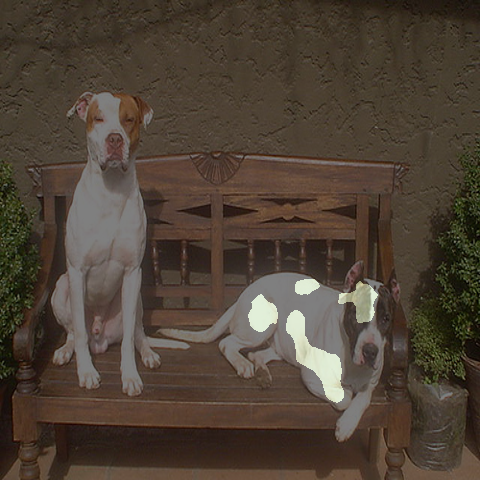

In [22]:
# show result
pred = (output.sigmoid().cpu().detach().squeeze() > 0.5).unsqueeze(-1)
color = torch.tensor([197,224,180]).unsqueeze(0)
pred_mask = Image.fromarray((pred*color).numpy().astype('uint8'))
print("Input text:", txt)
Image.blend(input_img.resize((480,480)), pred_mask, alpha=0.5)

In [23]:
model

ConvSegmentor_PEFT(
  (backbone): ReMamber_PEFT(
    (patch_embed): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): Identity()
      (2): LayerNorm2d((64,), eps=1e-05, elementwise_affine=True)
      (3): Identity()
      (4): GELU(approximate='none')
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (6): Identity()
      (7): LayerNorm2d((128,), eps=1e-05, elementwise_affine=True)
    )
    (layers): ModuleList(
      (0): Sequential(
        (blocks): Sequential(
          (0): VSSBlock(
            (norm): LayerNorm2d((128,), eps=1e-05, elementwise_affine=True)
            (op): SS2D(
              (out_norm): LayerNorm2d((256,), eps=1e-05, elementwise_affine=True)
              (in_proj): Linear2d(in_features=128, out_features=256, bias=False)
              (act): SiLU()
              (conv2d): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=256, bias=False)
              

In [59]:
for name, param in model.named_parameters():
    if any(adapter_name in name for adapter_name in ['dense_aligners', 'adapter1', 'adapter2', 'adapter3', 'neck_adapter']):
        param.requires_grad = True
    else:
        param.requires_grad = False


In [60]:
decoder_params = sum(p.numel() for p in model.decoder.parameters() if p.requires_grad)
print(f"Decoder Parameters: {decoder_params}")


Decoder Parameters: 1498624


In [61]:
decoder_params = sum(p.numel() for p in model.parameters())
print(f"Decoder Parameters: {decoder_params}")


Decoder Parameters: 267102576


In [62]:
model

ConvSegmentor_PEFT(
  (backbone): ReMamber_PEFT(
    (patch_embed): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): Identity()
      (2): LayerNorm2d((64,), eps=1e-05, elementwise_affine=True)
      (3): Identity()
      (4): GELU(approximate='none')
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (6): Identity()
      (7): LayerNorm2d((128,), eps=1e-05, elementwise_affine=True)
    )
    (layers): ModuleList(
      (0): Sequential(
        (blocks): Sequential(
          (0): VSSBlock(
            (norm): LayerNorm2d((128,), eps=1e-05, elementwise_affine=True)
            (op): SS2D(
              (out_norm): LayerNorm2d((256,), eps=1e-05, elementwise_affine=True)
              (in_proj): Linear2d(in_features=128, out_features=256, bias=False)
              (act): SiLU()
              (conv2d): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=256, bias=False)
              

In [63]:
def count_adapter_parameters(model):
    adapter_param_count = 0
    adapter_param_names = []

    for name, module in model.named_modules():
        if isinstance(module, (ConvDecoderAdapter, BasicConvAdapter, DenseAligner, CrossTwister)):
            for pname, param in module.named_parameters(recurse=False):
                adapter_param_count += param.numel()
                adapter_param_names.append(f"{name}.{pname}")
        elif 'adapter' in name.lower():  # Fallback for unnamed types, e.g., adapter3, neck_adapter
            for pname, param in module.named_parameters(recurse=False):
                adapter_param_count += param.numel()
                adapter_param_names.append(f"{name}.{pname}")

    print(f"Adapter parameters: {adapter_param_count:,}")
    return adapter_param_count, adapter_param_names


In [64]:
adapter_param_names

NameError: name 'adapter_param_names' is not defined

In [65]:
adapter_param_count, adapter_param_names = count_adapter_parameters(model)
adapter_param_count, #adapter_param_names

Adapter parameters: 12,524,399


(12524399,)

In [66]:
import torch
from torch import nn

def count_adapter_params(model):
    adapter_keywords = ['adapter', 'dense_aligners', 'block_adapters']
    total_params = 0

    for name, module in model.named_modules():
        if any(key in name for key in adapter_keywords):
            for param in module.parameters():
                total_params += param.numel()

    return total_params

# Usage
adapter_params = count_adapter_params(model)
print(f"Total adapter parameters: {adapter_params:,}")


Total adapter parameters: 76,459,593


In [67]:
model.parameters

<bound method Module.parameters of ConvSegmentor_PEFT(
  (backbone): ReMamber_PEFT(
    (patch_embed): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): Identity()
      (2): LayerNorm2d((64,), eps=1e-05, elementwise_affine=True)
      (3): Identity()
      (4): GELU(approximate='none')
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (6): Identity()
      (7): LayerNorm2d((128,), eps=1e-05, elementwise_affine=True)
    )
    (layers): ModuleList(
      (0): Sequential(
        (blocks): Sequential(
          (0): VSSBlock(
            (norm): LayerNorm2d((128,), eps=1e-05, elementwise_affine=True)
            (op): SS2D(
              (out_norm): LayerNorm2d((256,), eps=1e-05, elementwise_affine=True)
              (in_proj): Linear2d(in_features=128, out_features=256, bias=False)
              (act): SiLU()
              (conv2d): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), gro

In [68]:
dims = 128
use_checkpoint = True
norm_layer_key = config['norm_layer']


KeyError: 'norm_layer'

In [69]:
_NORMLAYERS = dict(ln=nn.LayerNorm, ln2d=LayerNorm2d, bn=nn.BatchNorm2d)
_ACTLAYERS  = dict(silu=nn.SiLU, gelu=nn.GELU, relu=nn.ReLU, sigmoid=nn.Sigmoid)
norm_layer    = _NORMLAYERS[config['norm_layer'].lower()]
ssm_act_layer = _ACTLAYERS[config['ssm_act_layer'].lower()]

KeyError: 'norm_layer'

In [70]:
mamba_config = {'patch_size': 4,
 'in_chans': 3,
 'num_classes': 1000,
 'depths': [2, 2, 15, 2],
 'dims': [128, 256, 512, 1024],
 'ssm_d_state': 1,
 'ssm_ratio': 2.0,
 'ssm_rank_ratio': 2.0,
 'ssm_dt_rank': 'auto',
 'ssm_act_layer': 'silu',
 'ssm_conv': 3,
 'ssm_conv_bias': False,
 'ssm_drop_rate': 0.0,
 'ssm_init': 'v0',
 'forward_type': 'v4noz',
 'mlp_ratio': 4.0,
 'mlp_act_layer': 'gelu',
 'mlp_drop_rate': 0.0,
 'drop_path_rate': 0.1,
 'patch_norm': True,
 'norm_layer': 'ln2d',
 'downsample_version': 'v3',
 'patchembed_version': 'v2',
 'gmlp': False,
 'use_checkpoint': False}

In [71]:
v = VSSLayer(
    dim=128,
    depth=2,
    use_checkpoint=use_checkpoint,
    norm_layer=norm_layer,
    ssm_act_layer=ssm_act_layer,
    downsample=None,
    channel_first=model.backbone.channel_first,
    # ===== SSM params
    ssm_d_state=mamba_config['ssm_d_state'],
    ssm_ratio=1,
    ssm_dt_rank=1,
    ssm_conv=mamba_config['ssm_conv'],
    ssm_conv_bias=mamba_config['ssm_conv_bias'],
    ssm_drop_rate=mamba_config['ssm_drop_rate'],
    ssm_init=mamba_config['ssm_init'],
    forward_type=mamba_config['forward_type'],
    # ===== MLPmamba_config
    mlp_ratio=mamba_config['mlp_ratio'],
    mlp_act_layer=mamba_config['mlp_act_layer'],
    mlp_drop_rate=mamba_config['mlp_drop_rate'],
    gmlp=mamba_config['gmlp'],
    forward_coremm='Twister',
)
v

NameError: name 'norm_layer' is not defined

In [72]:
v = ImageTextCorr(
    visual_dim=dims,
    text_dim=768,
    hidden_dim=512,
    out_dim=dims,
)
v

ImageTextCorr(
  (vis_proj): Sequential(
    (0): Linear(in_features=128, out_features=512, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.0, inplace=False)
  )
  (text_proj): Sequential(
    (0): Linear(in_features=768, out_features=512, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.0, inplace=False)
  )
  (unsqueeze): Sequential(
    (0): Conv2d(20, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): GELU(approximate='none')
    (2): Dropout(p=0.0, inplace=False)
  )
  (out_proj): Linear(in_features=512, out_features=128, bias=True)
)

In [73]:
v = ImageTextCorr(
    visual_dim=128,
    text_dim=128,
    hidden_dim=128,
    out_dim=128,
)
v

ImageTextCorr(
  (vis_proj): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.0, inplace=False)
  )
  (text_proj): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.0, inplace=False)
  )
  (unsqueeze): Sequential(
    (0): Conv2d(20, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): GELU(approximate='none')
    (2): Dropout(p=0.0, inplace=False)
  )
  (out_proj): Linear(in_features=128, out_features=128, bias=True)
)

In [74]:
sum(p.numel() for p in v.parameters() if p.requires_grad)


72704

In [75]:
update_mamba_config("base")

{'patch_size': 4,
 'in_chans': 3,
 'num_classes': 1000,
 'depths': [2, 2, 15, 2],
 'dims': [128, 256, 512, 1024],
 'ssm_d_state': 1,
 'ssm_ratio': 2.0,
 'ssm_rank_ratio': 2.0,
 'ssm_dt_rank': 'auto',
 'ssm_act_layer': 'silu',
 'ssm_conv': 3,
 'ssm_conv_bias': False,
 'ssm_drop_rate': 0.0,
 'ssm_init': 'v0',
 'forward_type': 'v4noz',
 'mlp_ratio': 4.0,
 'mlp_act_layer': 'gelu',
 'mlp_drop_rate': 0.0,
 'drop_path_rate': 0.1,
 'patch_norm': True,
 'norm_layer': 'ln2d',
 'downsample_version': 'v3',
 'patchembed_version': 'v2',
 'gmlp': False,
 'use_checkpoint': False}

In [76]:
import torch

# Assuming 'model' is your PyTorch model
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")

Total parameters: 267102576


In [77]:
model

ConvSegmentor_PEFT(
  (backbone): ReMamber_PEFT(
    (patch_embed): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): Identity()
      (2): LayerNorm2d((64,), eps=1e-05, elementwise_affine=True)
      (3): Identity()
      (4): GELU(approximate='none')
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (6): Identity()
      (7): LayerNorm2d((128,), eps=1e-05, elementwise_affine=True)
    )
    (layers): ModuleList(
      (0): Sequential(
        (blocks): Sequential(
          (0): VSSBlock(
            (norm): LayerNorm2d((128,), eps=1e-05, elementwise_affine=True)
            (op): SS2D(
              (out_norm): LayerNorm2d((256,), eps=1e-05, elementwise_affine=True)
              (in_proj): Linear2d(in_features=128, out_features=256, bias=False)
              (act): SiLU()
              (conv2d): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=256, bias=False)
              

In [78]:
model

ConvSegmentor_PEFT(
  (backbone): ReMamber_PEFT(
    (patch_embed): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): Identity()
      (2): LayerNorm2d((64,), eps=1e-05, elementwise_affine=True)
      (3): Identity()
      (4): GELU(approximate='none')
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (6): Identity()
      (7): LayerNorm2d((128,), eps=1e-05, elementwise_affine=True)
    )
    (layers): ModuleList(
      (0): Sequential(
        (blocks): Sequential(
          (0): VSSBlock(
            (norm): LayerNorm2d((128,), eps=1e-05, elementwise_affine=True)
            (op): SS2D(
              (out_norm): LayerNorm2d((256,), eps=1e-05, elementwise_affine=True)
              (in_proj): Linear2d(in_features=128, out_features=256, bias=False)
              (act): SiLU()
              (conv2d): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=256, bias=False)
              

In [79]:
# Load checkpoint
#checkpoint = torch.load("model_checkpoint.pth", map_location="cpu")

# If it contains the full model (not just state_dict)
m = model  # or checkpoint['model'] if it's stored under a key
total_params = sum(p.numel() for p in m.parameters())
print(f"Total parameters: {total_params}")

Total parameters: 267102576


In [80]:
model

ConvSegmentor_PEFT(
  (backbone): ReMamber_PEFT(
    (patch_embed): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): Identity()
      (2): LayerNorm2d((64,), eps=1e-05, elementwise_affine=True)
      (3): Identity()
      (4): GELU(approximate='none')
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (6): Identity()
      (7): LayerNorm2d((128,), eps=1e-05, elementwise_affine=True)
    )
    (layers): ModuleList(
      (0): Sequential(
        (blocks): Sequential(
          (0): VSSBlock(
            (norm): LayerNorm2d((128,), eps=1e-05, elementwise_affine=True)
            (op): SS2D(
              (out_norm): LayerNorm2d((256,), eps=1e-05, elementwise_affine=True)
              (in_proj): Linear2d(in_features=128, out_features=256, bias=False)
              (act): SiLU()
              (conv2d): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=256, bias=False)
              

In [10]:
model = demo_model

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0" # NOTE: use this to select GPU
import torch
from timm.models import create_model

import model.conv_segmenter
import model.mamba_segmenter
import utils as utils
from ref_dataset import get_transform_seg


DEVICE = torch.device("cuda")
SEED = 42
MODEL_NAME = "ReMamber_Conv" # "ReMamber_Mamba" or "ReMamber_Conv"
CKPT_PATH = "pretrain/vssm_base_0229_ckpt_epoch_237.pth"#"checkpoints/ReMamber_Mamba.pth"
CKPT_PATH = "pretrain/ReMamber_Conv.pth"

# prepare model and transforms
demo_model, new_param = create_model(
    MODEL_NAME,
    img_size=480,
    model_size="base",
)

checkpoint = torch.load(CKPT_PATH, map_location='cpu')
demo_model.load_state_dict(checkpoint['model'])
demo_model.to(DEVICE)
demo_model.eval()
transforms = get_transform_seg(size=(480,480), train=False)

['patch_embed.0.weight', 'patch_embed.0.bias', 'patch_embed.2.weight', 'patch_embed.2.bias', 'patch_embed.5.weight', 'patch_embed.5.bias', 'patch_embed.7.weight', 'patch_embed.7.bias', 'layers.0.blocks.0.norm.weight', 'layers.0.blocks.0.norm.bias', 'layers.0.blocks.0.op.x_proj_weight', 'layers.0.blocks.0.op.dt_projs_weight', 'layers.0.blocks.0.op.dt_projs_bias', 'layers.0.blocks.0.op.A_logs', 'layers.0.blocks.0.op.Ds', 'layers.0.blocks.0.op.out_norm.weight', 'layers.0.blocks.0.op.out_norm.bias', 'layers.0.blocks.0.op.in_proj.weight', 'layers.0.blocks.0.op.conv2d.weight', 'layers.0.blocks.0.op.out_proj.weight', 'layers.0.blocks.0.norm2.weight', 'layers.0.blocks.0.norm2.bias', 'layers.0.blocks.0.mlp.fc1.weight', 'layers.0.blocks.0.mlp.fc1.bias', 'layers.0.blocks.0.mlp.fc2.weight', 'layers.0.blocks.0.mlp.fc2.bias', 'layers.0.blocks.1.norm.weight', 'layers.0.blocks.1.norm.bias', 'layers.0.blocks.1.op.x_proj_weight', 'layers.0.blocks.1.op.dt_projs_weight', 'layers.0.blocks.1.op.dt_projs_bia

In [82]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0" # NOTE: use this to select GPU
import torch
from timm.models import create_model

import model.conv_segmenter
import model.mamba_segmenter
import utils as utils
from ref_dataset import get_transform_seg


DEVICE = torch.device("cuda")
SEED = 42
MODEL_NAME = "ReMamber_Conv" # "ReMamber_Mamba" or "ReMamber_Conv"
CKPT_PATH = "pretrain/vssm_base_0229_ckpt_epoch_237.pth"#"checkpoints/ReMamber_Mamba.pth"
CKPT_PATH = "pretrain/ReMamber_Conv.pth"

# prepare model and transforms
demo_model, new_param = create_model(
    MODEL_NAME,
    img_size=480,
    model_size="base",
)

checkpoint = torch.load(CKPT_PATH, map_location='cpu')
demo_model.load_state_dict(checkpoint['model'])
demo_model.to(DEVICE)
demo_model.eval()
transforms = get_transform_seg(size=(480,480), train=False)

['patch_embed.0.weight', 'patch_embed.0.bias', 'patch_embed.2.weight', 'patch_embed.2.bias', 'patch_embed.5.weight', 'patch_embed.5.bias', 'patch_embed.7.weight', 'patch_embed.7.bias', 'layers.0.blocks.0.norm.weight', 'layers.0.blocks.0.norm.bias', 'layers.0.blocks.0.op.x_proj_weight', 'layers.0.blocks.0.op.dt_projs_weight', 'layers.0.blocks.0.op.dt_projs_bias', 'layers.0.blocks.0.op.A_logs', 'layers.0.blocks.0.op.Ds', 'layers.0.blocks.0.op.out_norm.weight', 'layers.0.blocks.0.op.out_norm.bias', 'layers.0.blocks.0.op.in_proj.weight', 'layers.0.blocks.0.op.conv2d.weight', 'layers.0.blocks.0.op.out_proj.weight', 'layers.0.blocks.0.norm2.weight', 'layers.0.blocks.0.norm2.bias', 'layers.0.blocks.0.mlp.fc1.weight', 'layers.0.blocks.0.mlp.fc1.bias', 'layers.0.blocks.0.mlp.fc2.weight', 'layers.0.blocks.0.mlp.fc2.bias', 'layers.0.blocks.1.norm.weight', 'layers.0.blocks.1.norm.bias', 'layers.0.blocks.1.op.x_proj_weight', 'layers.0.blocks.1.op.dt_projs_weight', 'layers.0.blocks.1.op.dt_projs_bia

In [3]:
demo_model.text_encoder

CLIPTextModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 768)
      (position_embedding): Embedding(77, 768)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPSdpaAttention(
            (k_proj): Linear(in_features=768, out_features=768, bias=True)
            (v_proj): Linear(in_features=768, out_features=768, bias=True)
            (q_proj): Linear(in_features=768, out_features=768, bias=True)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear(in_features=3072, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), ep

In [8]:
demo_model

ConvSegmentor(
  (backbone): ReMamber(
    (patch_embed): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): Identity()
      (2): LayerNorm2d((64,), eps=1e-05, elementwise_affine=True)
      (3): Identity()
      (4): GELU(approximate='none')
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (6): Identity()
      (7): LayerNorm2d((128,), eps=1e-05, elementwise_affine=True)
    )
    (layers): ModuleList(
      (0): Sequential(
        (blocks): Sequential(
          (0): VSSBlock(
            (norm): LayerNorm2d((128,), eps=1e-05, elementwise_affine=True)
            (op): SS2D(
              (out_norm): LayerNorm2d((256,), eps=1e-05, elementwise_affine=True)
              (in_proj): Linear2d(in_features=128, out_features=256, bias=False)
              (act): SiLU()
              (conv2d): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=256, bias=False)
              (out_act):

In [15]:
# 2) Load your old BaseSegmenter checkpoint
ckpt = torch.load("pretrain/ReMamber_Conv.pth", map_location="cpu")["model"]

# 3) Extract only the text_encoder portion of the state dict
text_state = {
    k.replace("text_encoder.", ""): v
    for k, v in ckpt.items()
    if k.startswith("text_encoder.")
}


In [16]:
text_state

{'text_model.embeddings.token_embedding.weight': tensor([[-0.0012,  0.0368,  0.0221,  ...,  0.0158,  0.0046, -0.0219],
         [ 0.0152,  0.0262, -0.0132,  ..., -0.0037,  0.0002,  0.0121],
         [-0.0154, -0.0131,  0.0065,  ..., -0.0206, -0.0139, -0.0025],
         ...,
         [ 0.0102, -0.0030, -0.0150,  ..., -0.0084, -0.0206,  0.0114],
         [ 0.0012, -0.0005,  0.0039,  ..., -0.0029, -0.0004, -0.0019],
         [-0.0132,  0.0167,  0.0021,  ..., -0.0032, -0.0107,  0.0114]]),
 'text_model.embeddings.position_embedding.weight': tensor([[ 1.7137e-03, -1.7087e-03,  3.8379e-03,  ..., -2.3244e-03,
           1.1098e-04, -2.2766e-03],
         [-2.2897e-04, -9.3387e-05,  6.8706e-03,  ...,  1.4042e-03,
          -2.7976e-03, -3.4809e-03],
         [-1.7893e-03, -2.2941e-03, -1.2427e-03,  ..., -6.8461e-03,
          -8.4573e-03,  5.9562e-04],
         ...,
         [ 2.1575e-02,  5.5394e-03, -1.0141e-02,  ..., -6.4915e-03,
          -2.9483e-03,  3.7277e-03],
         [ 1.8819e-02,  7

In [18]:
import torch
from transformers import CLIPTextModel, CLIPTokenizerFast
from peft import LoraConfig, get_peft_model


# 4) Build a fresh CLIPTextModel & load those weights
base_text = CLIPTextModel.from_pretrained("openai/clip-vit-large-patch14")
base_text.load_state_dict(text_state, strict=True)



<All keys matched successfully>

In [9]:
m = demo_model.backbone
# Assuming `m` is your nn.Module
num_parameters = sum(p.numel() for p in m.parameters())

print(f"Number of parameters: {num_parameters}")


Number of parameters: 122033152


In [84]:
demo_model.text_encoder.config

CLIPTextConfig {
  "_attn_implementation_autoset": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "dropout": 0.0,
  "eos_token_id": 2,
  "hidden_act": "quick_gelu",
  "hidden_size": 768,
  "initializer_factor": 1.0,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-05,
  "max_position_embeddings": 77,
  "model_type": "clip_text_model",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 1,
  "projection_dim": 768,
  "torch_dtype": "float32",
  "transformers_version": "4.51.3",
  "vocab_size": 49408
}

In [85]:
demo_model.text_encoder.forward

<bound method CLIPTextModel.forward of CLIPTextModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 768)
      (position_embedding): Embedding(77, 768)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPSdpaAttention(
            (k_proj): Linear(in_features=768, out_features=768, bias=True)
            (v_proj): Linear(in_features=768, out_features=768, bias=True)
            (q_proj): Linear(in_features=768, out_features=768, bias=True)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear(in_features=3072, out_features=768, bias=True)
          )
      

In [86]:
import inspect

In [87]:
print(inspect.getsource(demo_model.text_encoder.forward))

    @can_return_tuple
    @add_start_docstrings_to_model_forward(CLIP_TEXT_INPUTS_DOCSTRING)
    @replace_return_docstrings(output_type=BaseModelOutputWithPooling, config_class=CLIPTextConfig)
    def forward(
        self,
        input_ids: Optional[torch.Tensor] = None,
        attention_mask: Optional[torch.Tensor] = None,
        position_ids: Optional[torch.Tensor] = None,
        output_attentions: Optional[bool] = None,
        output_hidden_states: Optional[bool] = None,
    ) -> BaseModelOutputWithPooling:
        r"""
        Returns:

        Examples:

        ```python
        >>> from transformers import AutoTokenizer, CLIPTextModel

        >>> model = CLIPTextModel.from_pretrained("openai/clip-vit-base-patch32")
        >>> tokenizer = AutoTokenizer.from_pretrained("openai/clip-vit-base-patch32")

        >>> inputs = tokenizer(["a photo of a cat", "a photo of a dog"], padding=True, return_tensors="pt")

        >>> outputs = model(**inputs)
        >>> last_hidden_sta

In [88]:
c = demo_model.text_encoder.forward.__code__

In [89]:
c.co_names

('pop',
 'hasattr',
 'config',
 'use_return_dict',
 'getattr',
 'set_attribute_for_modules',
 'to_tuple',
 'del_attribute_from_modules')

In [90]:
from peft import LoraConfig, get_peft_model, TaskType
from transformers import CLIPTextModel

base = CLIPTextModel.from_pretrained('openai/clip-vit-large-patch14')
lora_cfg = LoraConfig(
    task_type=TaskType.SEQ_CLS,    # encoder‑only
    inference_mode=False,
    r=8,                           # rank
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.1,
)
text_encoder = get_peft_model(base, lora_cfg)

In [ ]:
class BaseSegmenter(nn.Module):
    def __init__(self, backbone, **kwargs):
        super().__init__()
        self.backbone = backbone
        self.decoder = None

        self.tokenizer = CLIPTokenizerFast.from_pretrained(
            "openai/clip-vit-large-patch14"
        )

        # — load base CLIP text encoder —
        base_text = CLIPTextModel.from_pretrained(
            "openai/clip-vit-large-patch14"
        )

        # — configure LoRA —
        lora_cfg = LoraConfig(
            task_type=TaskType.SEQ_CLS,    # encoder‐only
            inference_mode=False,          # we’re fine‐tuning
            r=8,                           # LoRA rank
            lora_alpha=32,
            lora_dropout=0.1,
            target_modules=["q_proj", "k_proj", "v_proj", "out_proj"],
        )

        # — wrap with LoRA adapters (freezes base_text) —
        self.text_encoder = get_peft_model(base_text, lora_cfg)

def forward(self, x, text, mask=None, **kwargs):
        # Tokenize input text
        encoding = self.tokenizer(
            text,
            padding='max_length',
            truncation=True,
            max_length=20,
            return_tensors='pt'
        )
        input_ids = encoding['input_ids'].to(x.device, non_blocking=True)
        attention_mask = encoding['attention_mask'].to(x.device, non_blocking=True)

        # Encode text with LoRA-adapted encoder
        ret = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=False,
            return_dict=True
        )
        l_feats = ret.last_hidden_state  # (B, N_l, C)
        l_feats = l_feats.permute(0, 2, 1)  # (B, C, N_l)
        l_mask = attention_mask.unsqueeze(-1)  # (B, N_l, 1)

        # Extract optional pooled output
        pooler_out = ret.pooler_output if hasattr(ret, "pooler_output") else None

        # Pass through backbone and decoder
        features = self.backbone(x, l_feats, l_mask, pooler_out=pooler_out)
        x_c1, x_c2, x_c3, x_c4 = features
        pred = self.decoder([x_c4, x_c3, x_c2, x_c1], l_feats, l_mask)
        pred = F.interpolate(pred, x.shape[-2:], mode='bilinear', align_corners=True)

        # Compute loss during training
        if self.training:
            loss = dice_loss(pred, mask) + sigmoid_focal_loss(pred, mask, alpha=-1, gamma=0)
            return pred.detach(), mask, loss
        else:
            return pred.detach()


In [ ]:
def get_text_encoder_weights(
    checkpoint_path: str = "pretrain/ReMamber_Conv.pth"
) -> dict:
    """
    Load a BaseSegmenter checkpoint and extract only the text_encoder weights.

    Args:
        checkpoint_path (str): Path to the checkpoint file (.pth or .pt).
                               Defaults to "pretrain/ReMamber_Conv.pth".

    Returns:
        dict: A state_dict containing only the keys/values for the text_encoder,
              with the "text_encoder." prefix removed.
    """
    # Load the checkpoint (handles both plain state_dict and {"model": state_dict} formats)
    ckpt = torch.load(checkpoint_path, map_location="cpu")
    state_dict = ckpt["model"] if isinstance(ckpt, dict) and "model" in ckpt else ckpt

    # Extract text_encoder weights
    text_state = {
        k.replace("text_encoder.", ""): v
        for k, v in state_dict.items()
        if k.startswith("text_encoder.")
    }

    return text_state

get_text_encoder_weights()